# Hospital Patient Records Analysis

## Objective

This project analyzes hospital patient records to understand patient
characteristics, medical conditions, hospital admissions, treatment
patterns, and healthcare outcomes.

The analysis will focus on identifying patterns in the patient data
and determining whether factors such as age, medical condition,
admission type, and other patient characteristics are associated
with differences in healthcare outcomes.

The project will follow four main stages:

1. Basic data exploration
2. Data cleaning and preparation
3. Exploratory data analysis
4. Data visualization and interpretation

The aim is not only to describe the data, but also to identify
meaningful patterns that could support better healthcare decision-making.

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

%matplotlib inline

In [3]:
hospital_analysis = pd.read_csv('hospital data analysis.csv')

hospital_analysis.head()

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4


In [4]:
print('Rows, Columns:', hospital_analysis.shape)

print('\nColumn names:')
print(list(hospital_analysis.columns))

Rows, Columns: (984, 10)

Column names:
['Patient_ID', 'Age', 'Gender', 'Condition', 'Procedure', 'Cost', 'Length_of_Stay', 'Readmission', 'Outcome', 'Satisfaction']


In [5]:
hospital_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      984 non-null    int64 
 1   Age             984 non-null    int64 
 2   Gender          984 non-null    object
 3   Condition       984 non-null    object
 4   Procedure       984 non-null    object
 5   Cost            984 non-null    int64 
 6   Length_of_Stay  984 non-null    int64 
 7   Readmission     984 non-null    object
 8   Outcome         984 non-null    object
 9   Satisfaction    984 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 77.0+ KB


In [6]:
hospital_analysis.describe()

,Patient_ID,Age,Cost,Length_of_Stay,Satisfaction
count,984.000000,984.000000,984.000000,984.000000,984.000000
mean,500.329268,53.754065,8367.479675,37.663618,3.598577
std,288.979531,14.941135,7761.990976,19.595805,0.883002
min,1.000000,25.000000,100.000000,1.000000,2.000000
25%,250.750000,45.000000,1000.000000,21.000000,3.000000
50%,500.500000,55.000000,6000.000000,38.000000,4.000000
75%,750.250000,65.000000,15000.000000,54.250000,4.000000
max,1000.000000,78.000000,25000.000000,76.000000,5.000000


In [14]:
for column in hospital_analysis.select_dtypes(include="object").columns:
    print(f"\n{column}")
    print(hospital_analysis[column].value_counts(dropna=False))


Gender
Gender
Female    524
Male      460
Name: count, dtype: int64

Condition
Condition
Fractured Leg            67
Heart Attack             67
Fractured Arm            66
Stroke                   66
Cancer                   66
Hypertension             66
Appendicitis             66
Allergic Reaction        66
Heart Disease            65
Diabetes                 65
Respiratory Infection    65
Prostate Cancer          65
Childbirth               65
Kidney Stones            65
Osteoarthritis           64
Name: count, dtype: int64

Procedure
Procedure
Cast and Physical Therapy               67
Cardiac Catheterization                 67
X-Ray and Splint                        66
CT Scan and Medication                  66
Surgery and Chemotherapy                66
Medication and Counseling               66
Appendectomy                            66
Epinephrine Injection                   66
Angioplasty                             65
Insulin Therapy                         65
Antibiotics a

In [7]:
hospital_analysis.duplicated().sum()

np.int64(0)

In [8]:
hospital_analysis.dtypes

Patient_ID         int64
Age                int64
Gender            object
Condition         object
Procedure         object
Cost               int64
Length_of_Stay     int64
Readmission       object
Outcome           object
Satisfaction       int64
dtype: object

In [9]:
hospital_analysis.nunique()

Patient_ID        984
Age                22
Gender              2
Condition          15
Procedure          15
Cost               15
Length_of_Stay     76
Readmission         2
Outcome             2
Satisfaction        4
dtype: int64

In [10]:
hospital_analysis.isnull().sum()

Patient_ID        0
Age               0
Gender            0
Condition         0
Procedure         0
Cost              0
Length_of_Stay    0
Readmission       0
Outcome           0
Satisfaction      0
dtype: int64

In [11]:
hospital_analysis.isnull().sum().sort_values(ascending=False)

Patient_ID        0
Age               0
Gender            0
Condition         0
Procedure         0
Cost              0
Length_of_Stay    0
Readmission       0
Outcome           0
Satisfaction      0
dtype: int64

## Patient Demographics

I will first examine the demographic characteristics of the patients,
including age and gender, to understand the population represented
in the dataset.

In [16]:
hospital_analysis["Age"].describe()

count    984.000000
mean      53.754065
std       14.941135
min       25.000000
25%       45.000000
50%       55.000000
75%       65.000000
max       78.000000
Name: Age, dtype: float64

In [17]:
hospital_analysis["Gender"].value_counts()

Gender
Female    524
Male      460
Name: count, dtype: int64

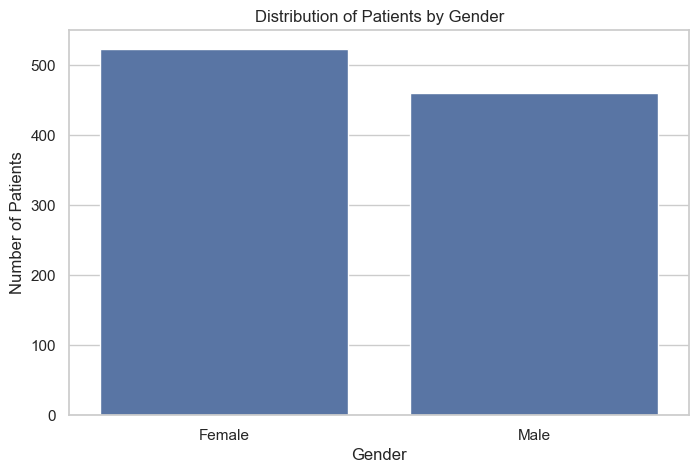

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=hospital_analysis, x="Gender")

plt.title("Distribution of Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

### Interpretation

The dataset contains 984 patients, with an average age of approximately 54 years. The patients range from 25 to 78 years old, showing that the dataset represents a fairly broad adult age range.

There are 524 female patients and 460 male patients. Therefore, females make up a slightly larger proportion of the dataset than males.

Although the difference between the two groups is not extremely large, gender should still be considered when examining medical conditions, procedures, and patient outcomes.

## Distribution of Medical Conditions

Understanding the most frequently recorded medical conditions can help identify the major health conditions represented in the dataset.

In [21]:
hospital_analysis["Condition"].value_counts()

Condition
Fractured Leg            67
Heart Attack             67
Fractured Arm            66
Stroke                   66
Cancer                   66
Hypertension             66
Appendicitis             66
Allergic Reaction        66
Heart Disease            65
Diabetes                 65
Respiratory Infection    65
Prostate Cancer          65
Childbirth               65
Kidney Stones            65
Osteoarthritis           64
Name: count, dtype: int64

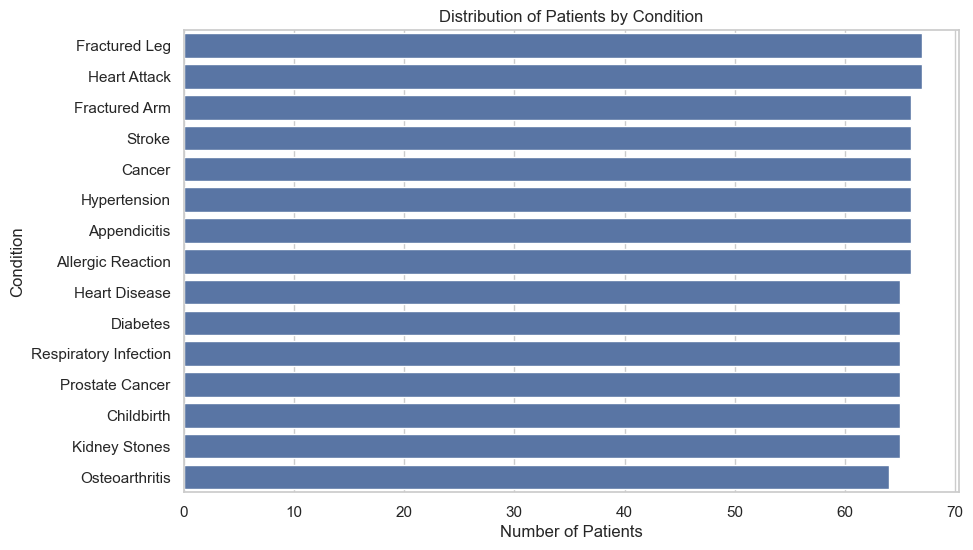

In [26]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=hospital_analysis,
    y="Condition",
    order=hospital_analysis["Condition"].value_counts().index
)

plt.title("Distribution of Patients by Condition")
plt.xlabel("Number of Patients")
plt.ylabel("Condition")
plt.show()

### Interpretation

The distribution of medical conditions is relatively balanced, with each condition having approximately 64 to 67 patients.

Fractured Leg and Heart Attack have the highest number of patients, with 67 cases each, while Osteoarthritis has the lowest with 64 cases.

Because the differences between conditions are small, there is no strong evidence from this dataset that one condition is overwhelmingly more common than the others.

This relatively balanced distribution is useful for comparison because no single condition dominates the dataset.

### Recommendation

Since the conditions are relatively evenly represented, further analysis should focus on how the conditions differ in terms of age, length of stay, cost, readmission, outcomes, and patient satisfaction rather than simply identifying the most frequent condition.

## Age and Medical Condition

I will investigate whether the age distribution differs across
medical conditions.

This may help determine whether certain conditions are more common
among older or younger patients within this dataset.

In [27]:
hospital_analysis.groupby("Condition")["Age"].mean().sort_values()

Condition
Allergic Reaction        26.454545
Fractured Arm            32.530303
Childbirth               33.446154
Fractured Leg            42.462687
Heart Disease            51.507692
Respiratory Infection    51.938462
Kidney Stones            52.492308
Appendicitis             52.651515
Cancer                   53.924242
Osteoarthritis           62.468750
Prostate Cancer          62.538462
Diabetes                 63.400000
Hypertension             70.000000
Stroke                   74.075758
Heart Attack             76.402985
Name: Age, dtype: float64

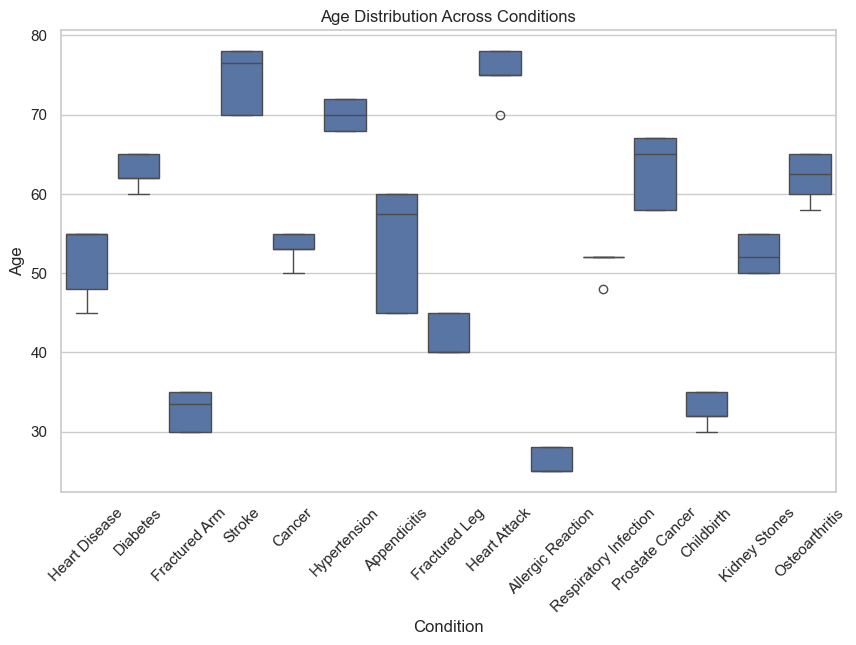

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=hospital_analysis,
    x="Condition",
    y="Age"
)

plt.title("Age Distribution Across Conditions")
plt.xlabel("Condition")
plt.ylabel("Age")

plt.xticks(rotation=45)

plt.show()

### Interpretation

The analysis shows substantial differences in the average age of patients across conditions.

Heart Attack and Stroke have the highest average patient ages, at approximately 76 and 74 years respectively. Hypertension also has a relatively high average age of 70 years.

In contrast, Allergic Reaction, Fractured Arm, and Childbirth have much lower average ages.

This suggests that age is associated with the type of medical condition recorded in this dataset. Conditions such as heart attack, stroke, hypertension, diabetes, and osteoarthritis appear more frequently among older patients, while conditions such as allergic reactions and fractures of the arm occur among younger patients on average.

However, this analysis shows an association rather than proving that age causes a particular condition.

### Recommendation

Healthcare providers could consider age when planning screening, prevention, and monitoring strategies. Older patients may require closer monitoring for conditions that are more common in the older age groups represented in this dataset.

However, additional clinical and demographic information would be required before making medical or population-level conclusions.

## Length of Hospital Stay

Length of stay is an important indicator of healthcare utilization. So, I will investigate whether length of stay differs across medical
conditions.

In [30]:
hospital_analysis["Length_of_Stay"].describe()

count    984.000000
mean      37.663618
std       19.595805
min        1.000000
25%       21.000000
50%       38.000000
75%       54.250000
max       76.000000
Name: Length_of_Stay, dtype: float64

In [32]:
hospital_analysis.groupby("Condition")["Length_of_Stay"].mean().sort_values(
    ascending=False
)

Condition
Cancer                   42.651515
Prostate Cancer          41.584615
Heart Attack             41.000000
Stroke                   40.333333
Fractured Leg            39.000000
Heart Disease            38.215385
Osteoarthritis           37.859375
Appendicitis             37.439394
Kidney Stones            36.461538
Diabetes                 36.092308
Childbirth               35.523077
Hypertension             35.515152
Respiratory Infection    34.661538
Fractured Arm            34.257576
Allergic Reaction        34.242424
Name: Length_of_Stay, dtype: float64

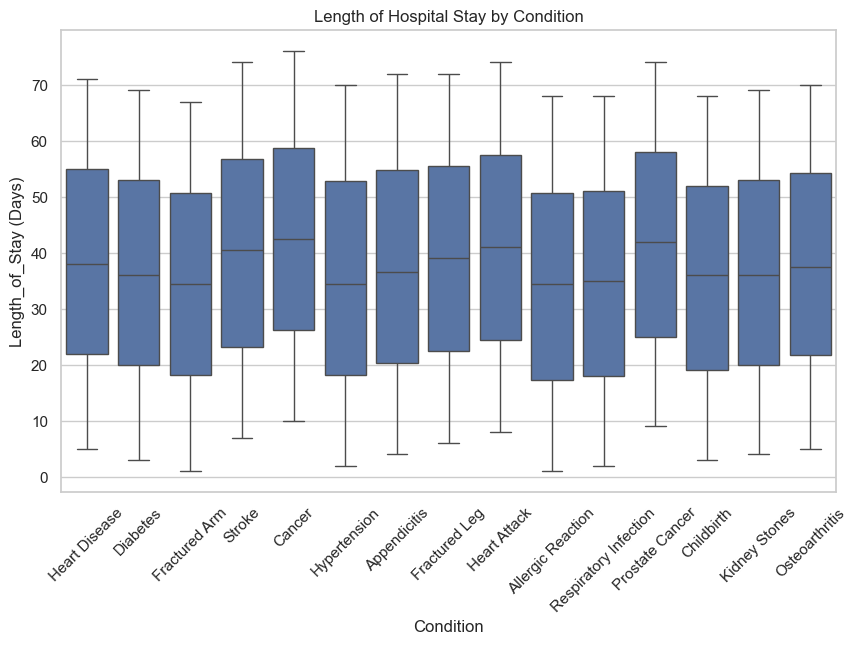

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=hospital_analysis,
    x="Condition",
    y="Length_of_Stay"
)

plt.title("Length of Hospital Stay by Condition")
plt.xlabel("Condition")
plt.ylabel("Length_of_Stay (Days)")

plt.xticks(rotation=45)

plt.show()

### Interpretation

The average length of hospital stay is approximately 38 days, although there is considerable variation between patients.

Cancer has the highest average length of stay at approximately 42.7 days, followed by Prostate Cancer, Heart Attack, and Stroke.

Allergic Reaction has the lowest average length of stay at approximately 34.2 days.

The differences suggest that some conditions may be associated with longer hospital stays than others. Conditions requiring more complex or prolonged care appear to have higher average lengths of stay in this dataset.

However, length of stay may also be influenced by factors such as treatment type, patient age, severity of illness, and complications, which are not all captured in the dataset.

### Recommendation

Hospital management could monitor conditions associated with longer stays to identify opportunities to improve care coordination and discharge planning.

Further analysis should examine whether longer stays are also associated with higher costs, readmissions, or lower patient satisfaction.

## Length of Stay and Cost

I will investigate whether patients who spend more days in the hospital tend to have higher costa.

This analysis can help determine whether hospital stay duration is associated with healthcare costs in the dataset.

In [35]:
hospital_analysis[["Length_of_Stay", "Cost"]].corr()

,Length_of_Stay,Cost
Length_of_Stay,1.000000,0.114206
Cost,0.114206,1.000000


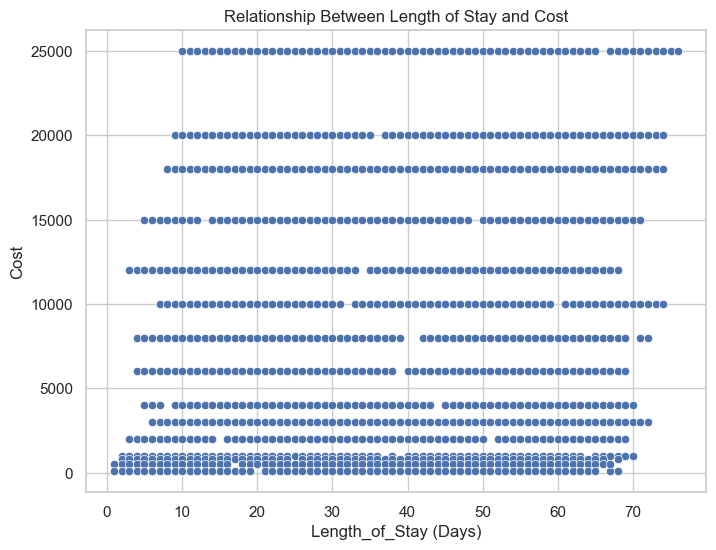

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=hospital_analysis,
    x="Length_of_Stay",
    y="Cost"
)

plt.title("Relationship Between Length of Stay and Cost")
plt.xlabel("Length_of_Stay (Days)")
plt.ylabel("Cost")

plt.show()

### Interpretation

The correlation between length of stay and cost is approximately 0.11.

This indicates a very weak positive relationship between the two variables. In this dataset, patients who stay longer in the hospital do not necessarily have substantially higher costs.

The scatter plot also shows considerable variation in cost across different lengths of stay.

Therefore, length of stay alone does not appear to be a strong predictor of healthcare cost in this dataset.

### Recommendation

Hospital cost should not be estimated based on length of stay alone.

Other factors, particularly medical condition, procedure, treatment intensity, and patient characteristics, should be investigated to better understand what drives healthcare costs.

## Medical Condition and Healthcare Costs

I will compare the average cost across conditions to determine whether some conditions are associated with higher healthcare costs in the dataset.

In [37]:
hospital_analysis.groupby("Condition")["Cost"].mean().sort_values(
    ascending=False
)

Condition
Cancer                   25000.0
Prostate Cancer          20000.0
Heart Attack             18000.0
Heart Disease            15000.0
Childbirth               12000.0
Stroke                   10000.0
Appendicitis              8000.0
Kidney Stones             6000.0
Osteoarthritis            4000.0
Fractured Leg             3000.0
Diabetes                  2000.0
Hypertension              1000.0
Respiratory Infection      800.0
Fractured Arm              500.0
Allergic Reaction          100.0
Name: Cost, dtype: float64

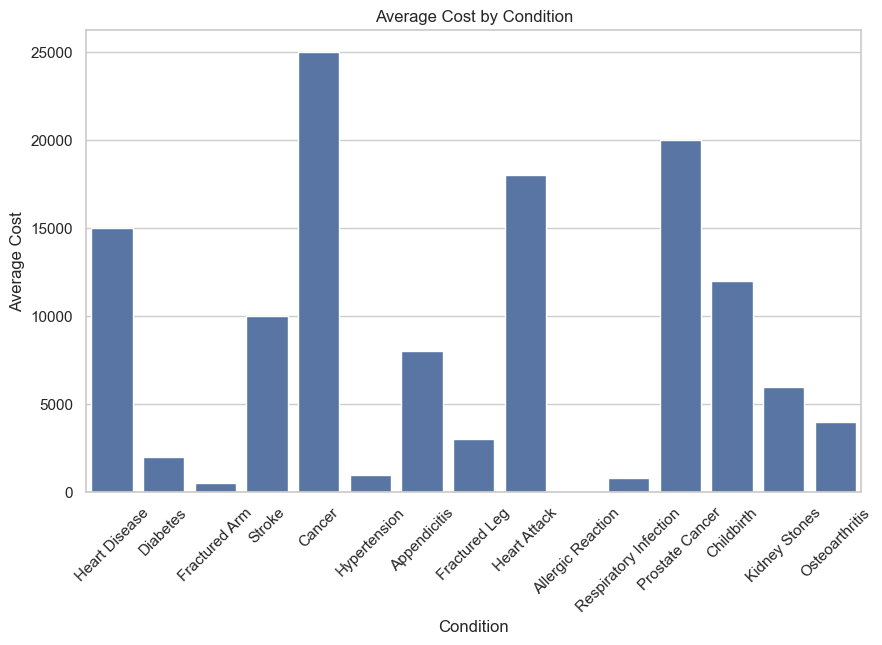

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=hospital_analysis,
    x="Condition",
    y="Cost",
    estimator="mean"
)

plt.title("Average Cost by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Cost")

plt.xticks(rotation=45)

plt.show()

### Interpretation

There are substantial differences in average healthcare cost across conditions.

Cancer has the highest average cost at 25,000, followed by Prostate Cancer, Heart Attack, and Heart Disease. Allergic Reaction has the lowest average cost at 100.

The large differences between conditions suggest that the type of medicalcondition is much more strongly associated with healthcare cost than length of stay alone.

This finding is consistent with the earlier correlation analysis, which showed only a weak relationship between length of stay and cost.

### Recommendation

Healthcare administrators should consider condition and treatment requirements when planning healthcare resources and budgets rather than relying
on length of stay alone.

High-cost conditions could be investigated further to understand which procedures or treatments contribute most to their costs.

## Analysis of Medical Procedures

Medical procedures represent an important part of patient treatment.

I will investigate the procedures performed in the dataset and examine whether procedure type is associated with patient age, healthcare cost, length of stay, readmission, and outcome.

This will help determine whether some procedures are associated with different patient characteristics and healthcare outcomes.

In [39]:
hospital_analysis["Procedure"].value_counts()

Procedure
Cast and Physical Therapy               67
Cardiac Catheterization                 67
X-Ray and Splint                        66
CT Scan and Medication                  66
Surgery and Chemotherapy                66
Medication and Counseling               66
Appendectomy                            66
Epinephrine Injection                   66
Angioplasty                             65
Insulin Therapy                         65
Antibiotics and Rest                    65
Radiation Therapy                       65
Delivery and Postnatal Care             65
Lithotripsy                             65
Physical Therapy and Pain Management    64
Name: count, dtype: int64

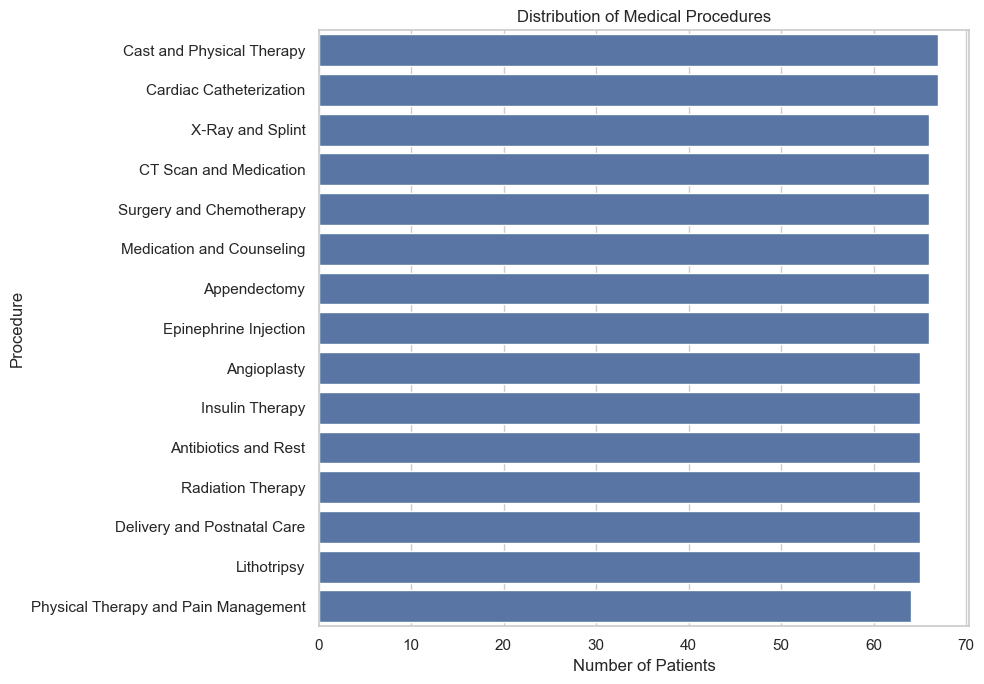

In [41]:
plt.figure(figsize=(10, 7))

sns.countplot(
    data=hospital_analysis,
    y="Procedure",
    order=hospital_analysis["Procedure"].value_counts().index
)

plt.title("Distribution of Medical Procedures")
plt.xlabel("Number of Patients")
plt.ylabel("Procedure")

plt.tight_layout()
plt.show()

In [42]:
pd.crosstab(
    hospital_analysis["Condition"],
    hospital_analysis["Procedure"]
)

Procedure,Angioplasty,Antibiotics and Rest,Appendectomy,CT Scan and Medication,Cardiac Catheterization,Cast and Physical Therapy,Delivery and Postnatal Care,Epinephrine Injection,Insulin Therapy,Lithotripsy,Medication and Counseling,Physical Therapy and Pain Management,Radiation Therapy,Surgery and Chemotherapy,X-Ray and Splint
Condition,,,,,,,,,,,,,,,
Allergic Reaction,0,0,0,0,0,0,0,66,0,0,0,0,0,0,0
Appendicitis,0,0,66,0,0,0,0,0,0,0,0,0,0,0,0
Cancer,0,0,0,0,0,0,0,0,0,0,0,0,0,66,0
Childbirth,0,0,0,0,0,0,65,0,0,0,0,0,0,0,0
Diabetes,0,0,0,0,0,0,0,0,65,0,0,0,0,0,0
Fractured Arm,0,0,0,0,0,0,0,0,0,0,0,0,0,0,66
Fractured Leg,0,0,0,0,0,67,0,0,0,0,0,0,0,0,0
Heart Attack,0,0,0,0,67,0,0,0,0,0,0,0,0,0,0
Heart Disease,65,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Condition and Procedure Relationship

The cross-tabulation shows that procedures are strongly associated with the conditions in this dataset. Each condition is primarily linked to a
specific procedure.

This means that procedure type should not be interpreted as completely independent of medical condition. Differences in procedure cost or outcome may
partly reflect differences in the underlying condition.

Therefore, when evaluating procedures, medical condition should also be considered to avoid attributing differences entirely to the procedure itself.



## Age and Medical Procedures

I will investigate whether the average age of patients differs across procedures.

This may reveal whether certain procedures are more commonly performed among younger or older patients.

The analysis will help determine whether procedure patterns reflect differences in the age profile of the patients receiving them.

In [43]:
hospital_analysis.groupby("Procedure")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean")

,count,mean,median,min,max
Procedure,,,,,
Epinephrine Injection,66,26.454545,25.0,25,28
X-Ray and Splint,66,32.530303,33.5,30,35
Delivery and Postnatal Care,65,33.446154,32.0,30,35
Cast and Physical Therapy,67,42.462687,40.0,40,45
Angioplasty,65,51.507692,55.0,45,55
Antibiotics and Rest,65,51.938462,52.0,48,52
Lithotripsy,65,52.492308,52.0,50,55
Appendectomy,66,52.651515,57.5,45,60
Surgery and Chemotherapy,66,53.924242,53.0,50,55


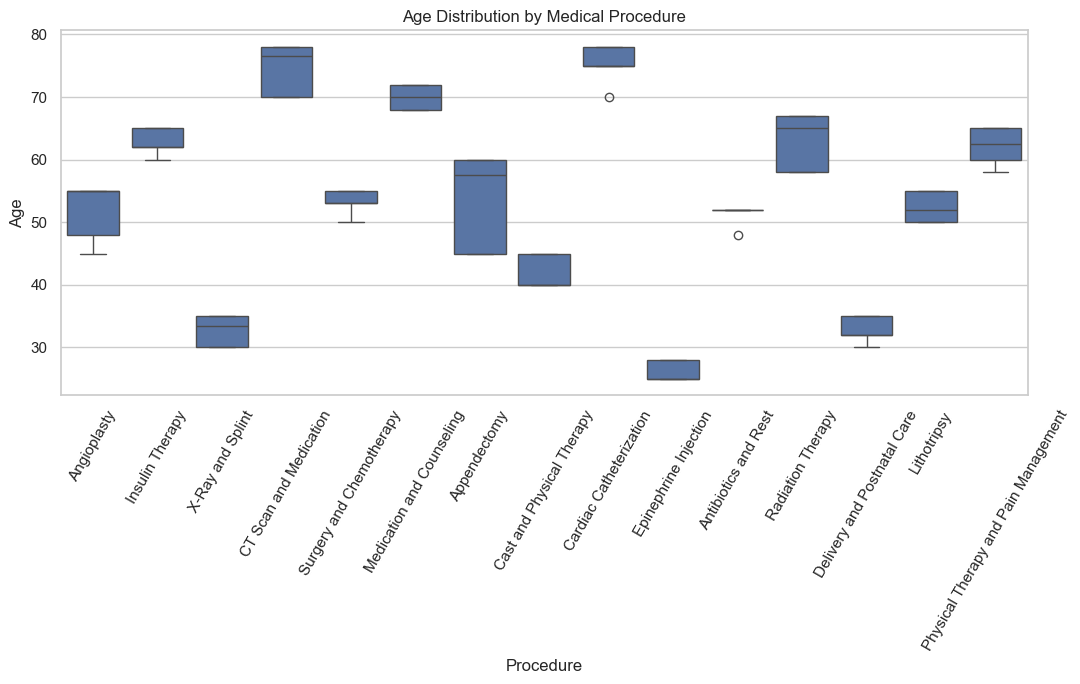

In [44]:
plt.figure(figsize=(11, 7))

sns.boxplot(
    data=hospital_analysis,
    x="Procedure",
    y="Age"
)

plt.title("Age Distribution by Medical Procedure")
plt.xlabel("Procedure")
plt.ylabel("Age")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

### Interpretation

There is a noticeable difference in the ages of patients receiving different procedures.

For example, patients receiving Epinephrine Injection have a much lower average age (approximately 26 years), while patients receiving Cardiac Catheterization have a much higher average age (approximately 76 years).

This suggests that procedure type is strongly associated with the age distribution of patients in this dataset.

However, age itself may not be the direct reason for the procedure. The medical condition associated with the procedure is likely an important factor. For example, procedures such as cardiac catheterization are associated with conditions that are more common among older patients.

Therefore, the next question is whether the relationship between age and procedure is actually explained by the patient's medical condition.

### Recommendation

Healthcare providers could consider age when planning treatment pathways and resource allocation, particularly for procedures involving older patients.

However, age should not be considered in isolation. Further analysis of age, condition, and procedure together would provide a better understanding of treatment patterns.

## Procedure and Healthcare Cost

I will compare healthcare costs across procedures to determine whether some procedures are associated with substantially higher costs.

This analysis may help identify procedures that require greater financial resources within the dataset.

In [45]:
procedure_cost = hospital_analysis.groupby("Procedure")["Cost"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False)

procedure_cost

,count,mean,median,min,max
Procedure,,,,,
Surgery and Chemotherapy,66,25000.0,25000.0,25000,25000
Radiation Therapy,65,20000.0,20000.0,20000,20000
Cardiac Catheterization,67,18000.0,18000.0,18000,18000
Angioplasty,65,15000.0,15000.0,15000,15000
Delivery and Postnatal Care,65,12000.0,12000.0,12000,12000
CT Scan and Medication,66,10000.0,10000.0,10000,10000
Appendectomy,66,8000.0,8000.0,8000,8000
Lithotripsy,65,6000.0,6000.0,6000,6000
Physical Therapy and Pain Management,64,4000.0,4000.0,4000,4000


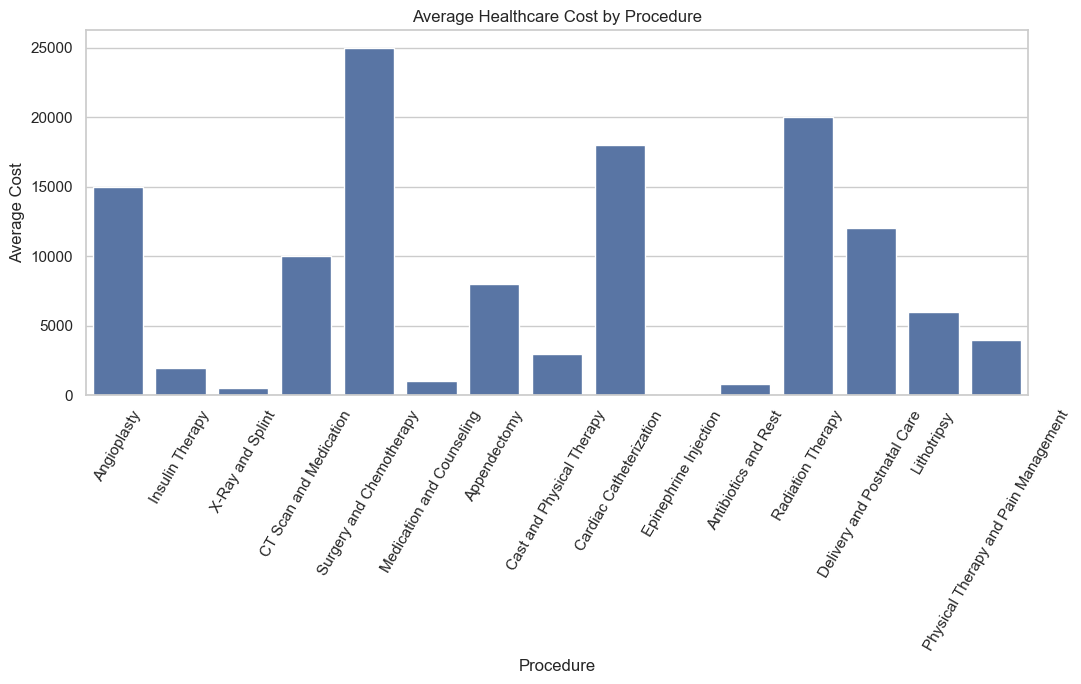

In [46]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=hospital_analysis,
    x="Procedure",
    y="Cost",
    estimator="mean"
)

plt.title("Average Healthcare Cost by Procedure")
plt.xlabel("Procedure")
plt.ylabel("Average Cost")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

### Interpretation

Healthcare costs vary considerably across procedures.

Procedures involving more complex treatment or multiple components are expected to require greater resources, which may contribute to higher costs.

However, procedure cost should not be interpreted as a measure of treatment quality. A higher-cost procedure may simply reflect the complexity of the condition being treated.

Therefore, cost should be examined alongside outcome, length of stay, and readmission rather than considered independently.

### Recommendation

Hospital management could monitor the cost distribution of major procedures and investigate unusually expensive cases.

Cost analysis should be combined with patient outcomes and length of stay to determine whether higher expenditure is associated with better healthcare outcomes.

## Procedure and Length of Hospital Stay

The length of hospital stay may differ depending on the type of procedure performed.

This analysis compares the average and distribution of hospital stays across procedures to identify procedures associated with longer or shorter stays.

In [48]:
hospital_analysis.groupby("Procedure")["Length_of_Stay"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False)

,count,mean,median,min,max
Procedure,,,,,
Surgery and Chemotherapy,66,42.651515,42.5,10,76
Radiation Therapy,65,41.584615,42.0,9,74
Cardiac Catheterization,67,41.000000,41.0,8,74
CT Scan and Medication,66,40.333333,40.5,7,74
Cast and Physical Therapy,67,39.000000,39.0,6,72
Angioplasty,65,38.215385,38.0,5,71
Physical Therapy and Pain Management,64,37.859375,37.5,5,70
Appendectomy,66,37.439394,36.5,4,72
Lithotripsy,65,36.461538,36.0,4,69


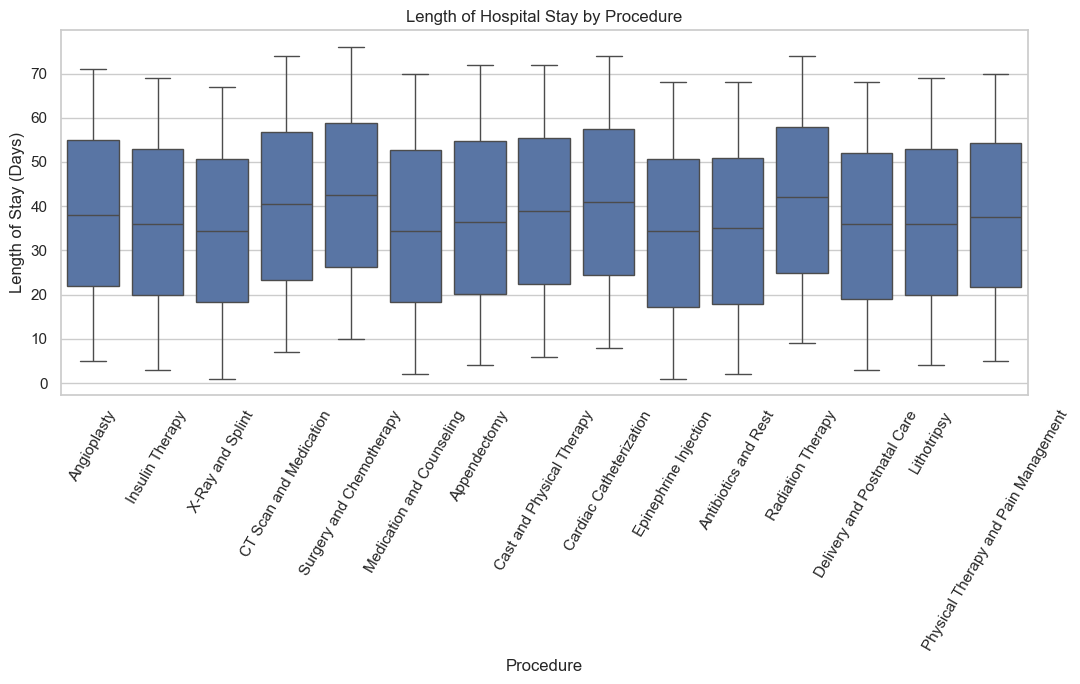

In [49]:
plt.figure(figsize=(11, 7))

sns.boxplot(
    data=hospital_analysis,
    x="Procedure",
    y="Length_of_Stay"
)

plt.title("Length of Hospital Stay by Procedure")
plt.xlabel("Procedure")
plt.ylabel("Length of Stay (Days)")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Procedure and Patient Outcome

The outcome variable provides an indication of the patient's condition at the end of the recorded hospital episode.

I will investigate whether patient outcomes differ across procedures.

This analysis can help identify whether certain procedures are associated with higher proportions of recovered or stable patients.

However, the analysis cannot establish that a procedure caused a particular outcome because patient condition and other factors may also influence outcomes.

In [50]:
procedure_outcome = pd.crosstab(
    hospital_analysis["Procedure"],
    hospital_analysis["Outcome"],
    normalize="index"
) * 100

procedure_outcome.round(2)

Outcome,Recovered,Stable
Procedure,,
Angioplasty,100.0,0.0
Antibiotics and Rest,0.0,100.0
Appendectomy,100.0,0.0
CT Scan and Medication,0.0,100.0
Cardiac Catheterization,0.0,100.0
Cast and Physical Therapy,100.0,0.0
Delivery and Postnatal Care,100.0,0.0
Epinephrine Injection,100.0,0.0
Insulin Therapy,0.0,100.0


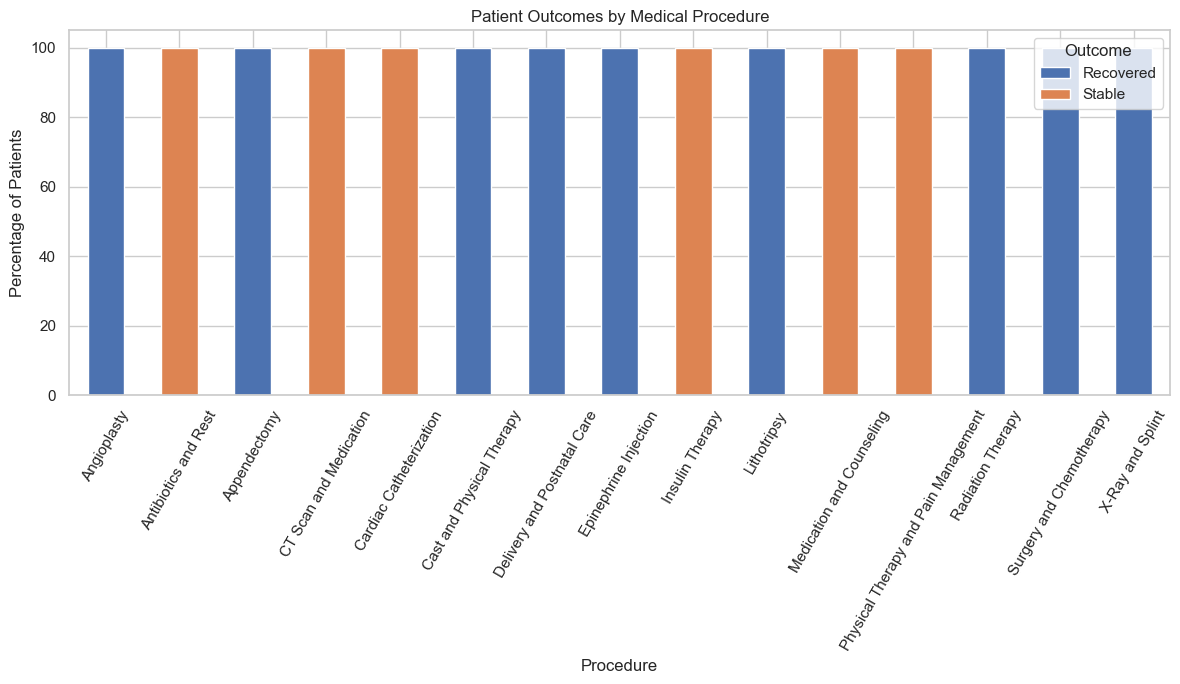

In [51]:
procedure_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Patient Outcomes by Medical Procedure")
plt.xlabel("Procedure")
plt.ylabel("Percentage of Patients")
plt.xticks(rotation=60)
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

### Interpretation

The proportion of recovered and stable patients varies across procedures.

This suggests that procedure type may be associated with differences in patient outcomes within the dataset.

However, procedure type alone does not determine the outcome. The patient's underlying condition, age, and severity of illness may also influence recovery.

Therefore, these results should be interpreted as associations rather than evidence that a particular procedure causes better or worse outcomes.

### Recommendation

Procedures associated with lower recovery proportions should be investigated further by examining the underlying conditions and patient characteristics involved.

Hospitals should evaluate treatment outcomes together with patient risk factors rather than judging procedures using outcome percentages alone.

## Procedure and Readmission

Readmission may provide an indication of whether patients return to the hospital after their initial treatment.

I will investigate whether readmission rates differ across procedures.

A higher readmission rate for a procedure may indicate the need for further investigation into follow-up care, patient recovery, or other factors.

However, readmission alone cannot be used to conclude that a procedure was unsuccessful.

In [52]:
procedure_readmission = pd.crosstab(
    hospital_analysis["Procedure"],
    hospital_analysis["Readmission"],
    normalize="index"
) * 100

procedure_readmission.round(2)

Readmission,No,Yes
Procedure,,
Angioplasty,1.54,98.46
Antibiotics and Rest,100.00,0.00
Appendectomy,50.00,50.00
CT Scan and Medication,50.00,50.00
Cardiac Catheterization,0.00,100.00
Cast and Physical Therapy,100.00,0.00
Delivery and Postnatal Care,100.00,0.00
Epinephrine Injection,100.00,0.00
Insulin Therapy,98.46,1.54


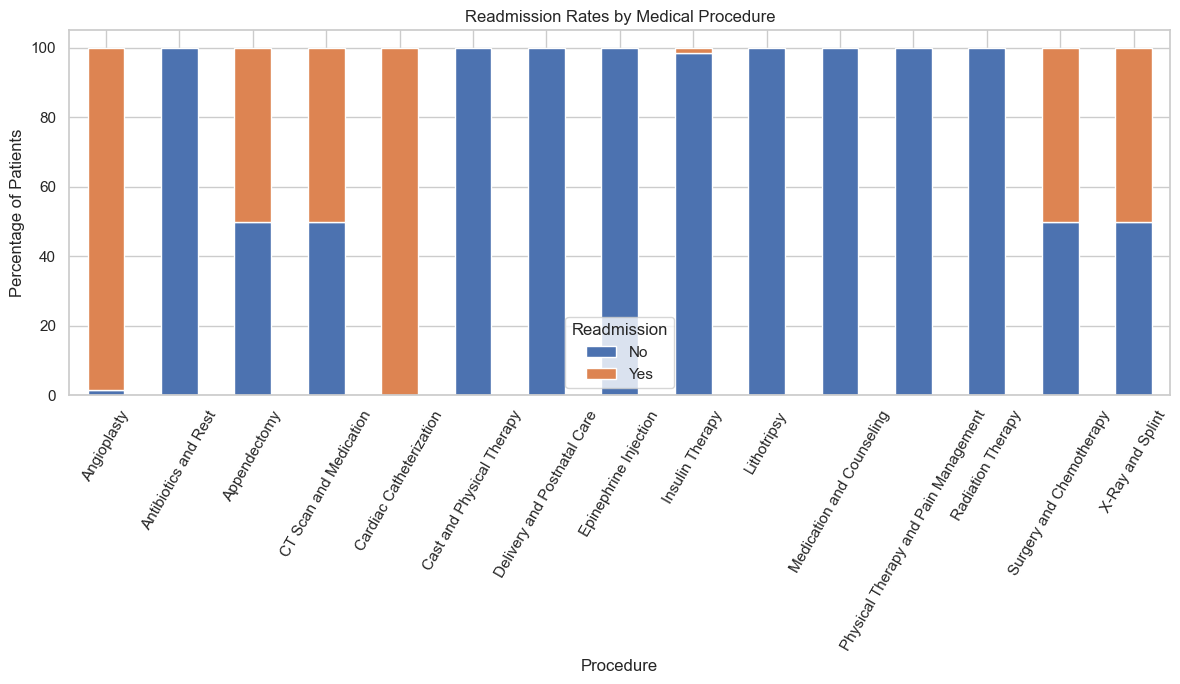

In [53]:
procedure_readmission.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Readmission Rates by Medical Procedure")
plt.xlabel("Procedure")
plt.ylabel("Percentage of Patients")
plt.xticks(rotation=60)
plt.legend(title="Readmission")

plt.tight_layout()
plt.show()

### Interpretation

Readmission rates vary across medical procedures, indicating that some procedures are associated with a greater proportion of patients returning to the hospital.

However, a higher readmission rate does not necessarily mean that the procedure was unsuccessful. Readmission can be influenced by the patient's underlying condition, age, complications, follow-up care, or other factors that are not captured in the dataset.

The procedure should therefore be viewed as one possible factor rather than the direct cause of readmission.

### Recommendation

Procedures with relatively high readmission rates should be investigated further to determine whether the pattern is related to the procedure itself or to the types of patients receiving it.

Hospitals could also strengthen post-discharge follow-up for patients considered at higher risk of readmission.

In [54]:
pd.crosstab(
    hospital_analysis["Readmission"],
    hospital_analysis["Outcome"],
    normalize="index"
).round(2) * 100

Outcome,Recovered,Stable
Readmission,,
No,59.0,41.0
Yes,62.0,38.0


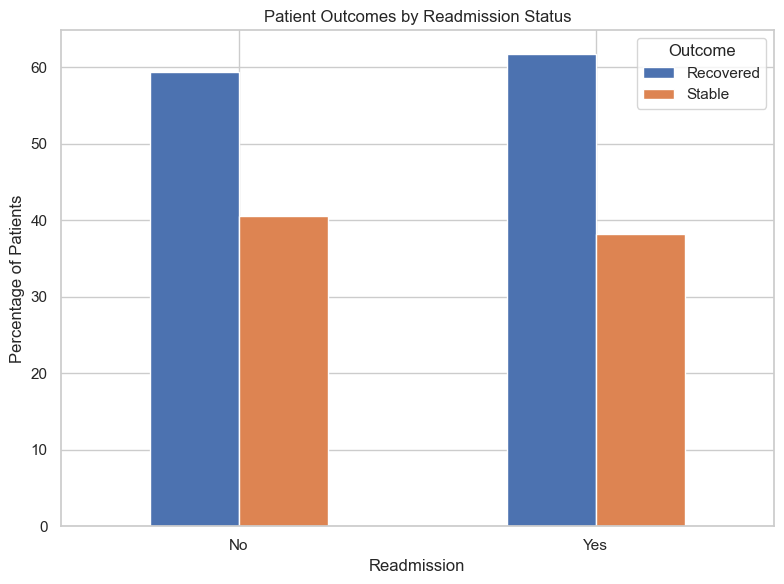

In [55]:
readmission_outcome = pd.crosstab(
    hospital_analysis["Readmission"],
    hospital_analysis["Outcome"],
    normalize="index"
) * 100

readmission_outcome.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Patient Outcomes by Readmission Status")
plt.xlabel("Readmission")
plt.ylabel("Percentage of Patients")
plt.xticks(rotation=0)
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

### Interpretation

The outcome distribution is relatively similar between patients who were readmitted and those who were not.

Among patients who were readmitted, 62% were recorded as recovered and 38% as stable. Among patients who were not readmitted, 59% were recovered and 41% were stable.

The small difference suggests that readmission does not appear to have a strong relationship with the recorded outcome in this dataset.

This is an important finding because it shows that readmission should not automatically be interpreted as treatment failure.

## Readmission and Patient Outcome

This analysis examines whether patient outcomes differ between patients who were readmitted and those who were not.

The purpose is to determine whether readmission is associated with differences in the recorded patient outcome.

## Gender and Medical Conditions

The overall dataset contains slightly more female than male patients.

However, overall gender distribution does not show whether particular medical conditions are more common within one gender.

Therefore, this analysis compares the distribution of conditions within each gender using percentages rather than raw counts.

This allows conditions to be compared fairly despite the difference in the number of male and female patients.

In [56]:
gender_condition = pd.crosstab(
    hospital_analysis["Condition"],
    hospital_analysis["Gender"]
)

gender_condition

Gender,Female,Male
Condition,,
Allergic Reaction,0,66
Appendicitis,66,0
Cancer,66,0
Childbirth,65,0
Diabetes,0,65
Fractured Arm,66,0
Fractured Leg,0,67
Heart Attack,67,0
Heart Disease,65,0


In [57]:
gender_condition_pct = pd.crosstab(
    hospital_analysis["Gender"],
    hospital_analysis["Condition"],
    normalize="index"
) * 100

gender_condition_pct.round(2)

Condition,Allergic Reaction,Appendicitis,Cancer,Childbirth,Diabetes,Fractured Arm,Fractured Leg,Heart Attack,Heart Disease,Hypertension,Kidney Stones,Osteoarthritis,Prostate Cancer,Respiratory Infection,Stroke
Gender,,,,,,,,,,,,,,,
Female,0.00,12.6,12.6,12.4,0.00,12.6,0.00,12.79,12.4,0.00,0.00,12.21,0.00,12.4,0.00
Male,14.35,0.0,0.0,0.0,14.13,0.0,14.57,0.00,0.0,14.35,14.13,0.00,14.13,0.0,14.35


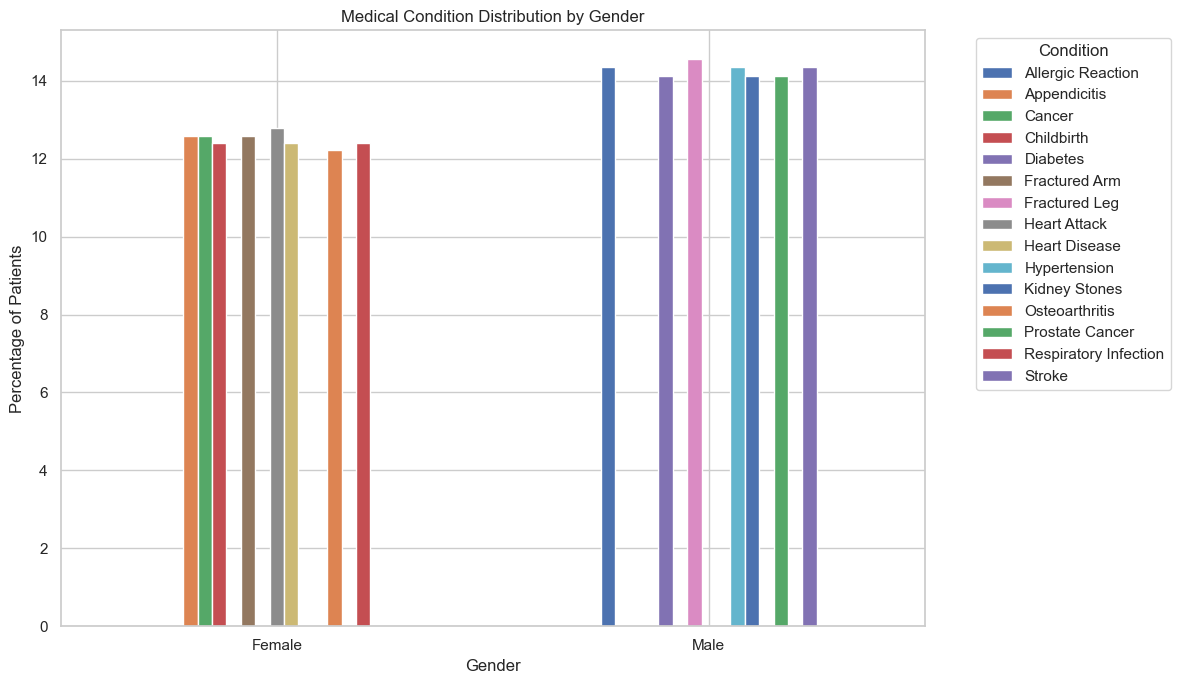

In [58]:
gender_condition_pct.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Medical Condition Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Patients")
plt.xticks(rotation=0)

plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of male and female patients varies across medical conditions. Some conditions show a relatively balanced gender distribution, while others show a clearer difference between male and female patients.

These differences should not automatically be interpreted as evidence that gender causes a particular condition. The dataset does not contain information about biological, lifestyle, or demographic factors that could explain these differences.

The analysis is therefore useful for identifying patterns that may require further investigation rather than establishing causation.

### Recommendation

Healthcare providers could monitor gender differences in patient presentations to determine whether certain conditions require more targeted prevention, screening, or patient education.

Further analysis using a larger and more representative dataset would be needed to determine whether the observed differences reflect genuine population-level patterns.

In [59]:
gender_procedure = pd.crosstab(
    hospital_analysis["Gender"],
    hospital_analysis["Procedure"],
    normalize="index"
) * 100

gender_procedure.round(2)


Procedure,Angioplasty,Antibiotics and Rest,Appendectomy,CT Scan and Medication,Cardiac Catheterization,Cast and Physical Therapy,Delivery and Postnatal Care,Epinephrine Injection,Insulin Therapy,Lithotripsy,Medication and Counseling,Physical Therapy and Pain Management,Radiation Therapy,Surgery and Chemotherapy,X-Ray and Splint
Gender,,,,,,,,,,,,,,,
Female,12.4,12.4,12.6,0.00,12.79,0.00,12.4,0.00,0.00,0.00,0.00,12.21,0.00,12.6,12.6
Male,0.0,0.0,0.0,14.35,0.00,14.57,0.0,14.35,14.13,14.13,14.35,0.00,14.13,0.0,0.0


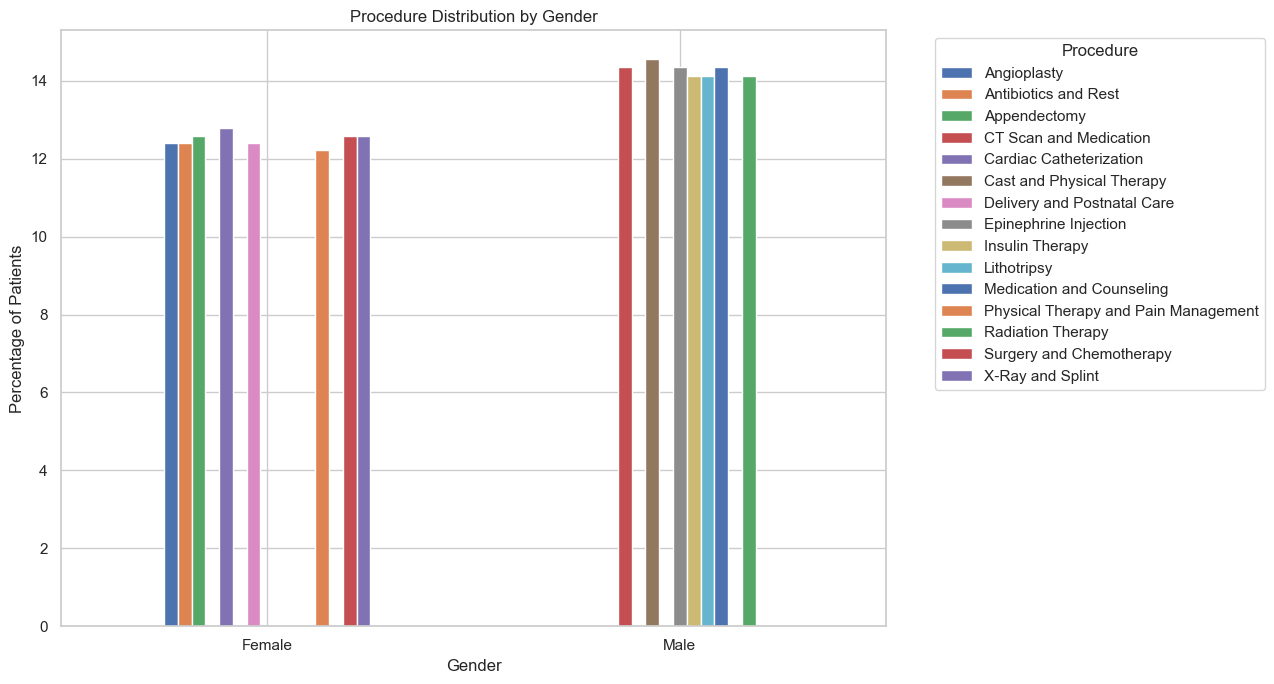

In [60]:
gender_procedure.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title("Procedure Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Patients")
plt.xticks(rotation=0)

plt.legend(title="Procedure", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Patient Satisfaction

Patient satisfaction provides an additional perspective on healthcare quality.

A patient may recover successfully while still reporting a poor experience, or may report high satisfaction despite a longer hospital stay.

Therefore, satisfaction should be examined alongside clinical outcomes, cost, length of stay, and readmission.

In [61]:
hospital_analysis["Satisfaction"].value_counts().sort_index()

Satisfaction
2    133
3    261
4    458
5    132
Name: count, dtype: int64

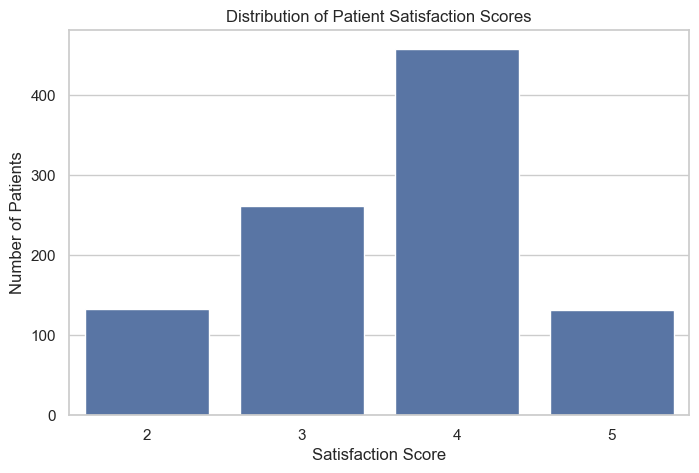

In [62]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=hospital_analysis,
    x="Satisfaction",
    order=sorted(hospital_analysis["Satisfaction"].unique())
)

plt.title("Distribution of Patient Satisfaction Scores")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Patients")

plt.show()

## Patient Satisfaction by Procedure

This analysis compares average satisfaction scores across medical procedures.

The purpose is to determine whether patient satisfaction differs according to the type of procedure received.

Differences in satisfaction may reflect factors such as treatment experience, length of stay, recovery, or patient expectations. However, the dataset does not contain enough information to identify the exact reason for differences in satisfaction.

In [63]:
hospital_analysis.groupby("Procedure")["Satisfaction"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
Procedure,,,
Epinephrine Injection,66,5.000000,5.0
X-Ray and Splint,66,5.000000,5.0
Antibiotics and Rest,65,4.000000,4.0
Cast and Physical Therapy,67,4.000000,4.0
Delivery and Postnatal Care,65,4.000000,4.0
Medication and Counseling,66,4.000000,4.0
Physical Therapy and Pain Management,64,4.000000,4.0
Surgery and Chemotherapy,66,4.000000,4.0
Insulin Therapy,65,3.507692,4.0


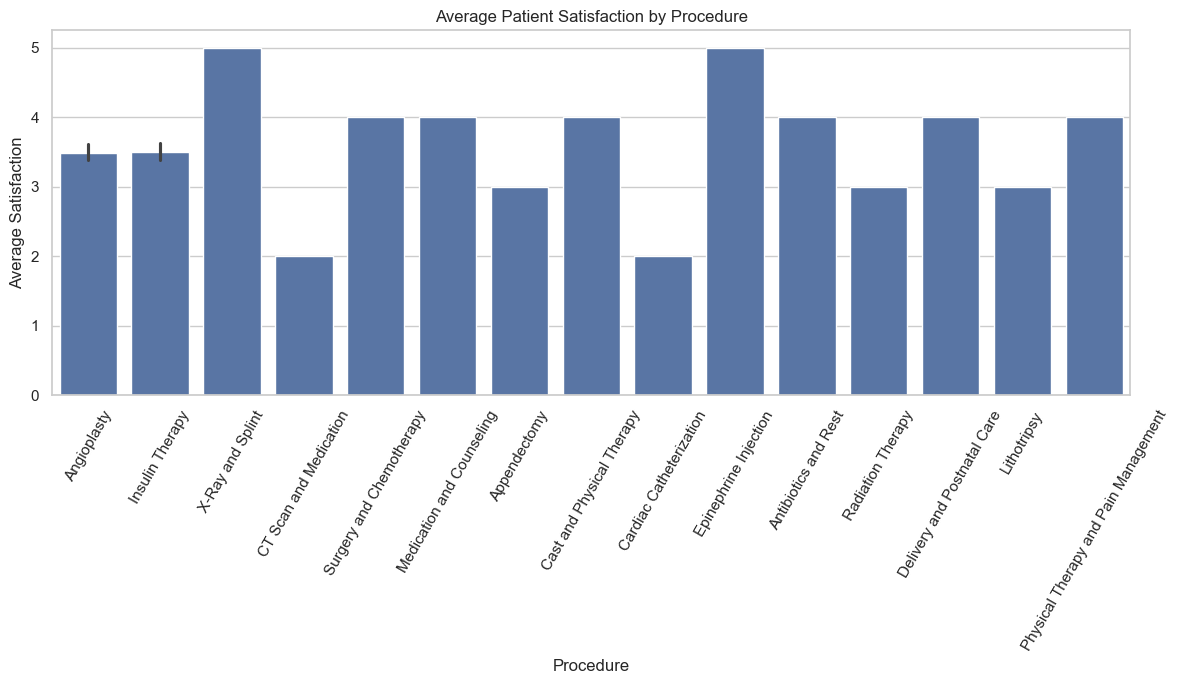

In [64]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=hospital_analysis,
    x="Procedure",
    y="Satisfaction",
    estimator="mean"
)

plt.title("Average Patient Satisfaction by Procedure")
plt.xlabel("Procedure")
plt.ylabel("Average Satisfaction")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Length of Stay and Patient Satisfaction

This analysis investigates whether the duration of hospitalization is associated with patient satisfaction.

A longer hospital stay may potentially influence a patient's experience, but then relationship should be evaluated using the data rather than assumed beforehand.

In [65]:
hospital_analysis[["Length_of_Stay", "Satisfaction"]].corr()

,Length_of_Stay,Satisfaction
Length_of_Stay,1.000000,-0.080891
Satisfaction,-0.080891,1.000000


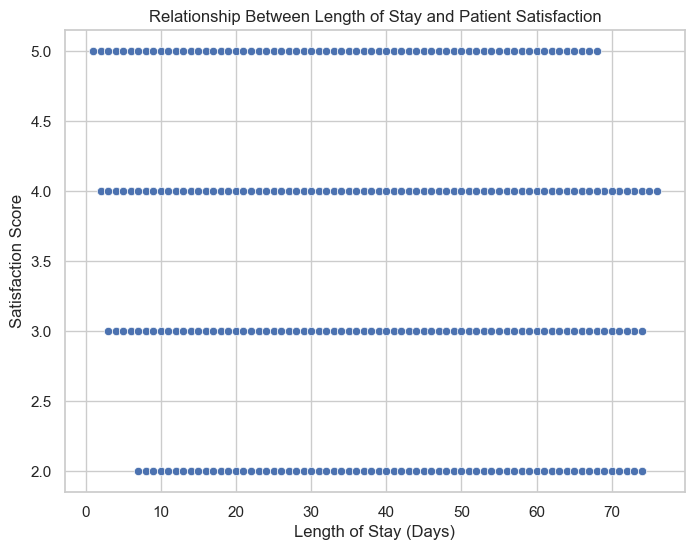

In [66]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=hospital_analysis,
    x="Length_of_Stay",
    y="Satisfaction"
)

plt.title("Relationship Between Length of Stay and Patient Satisfaction")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Satisfaction Score")

plt.show()

## Does Patient Outcome Affect Satisfaction?

I will examine whether patients with different recorded outcomes report different levels of satisfaction.

This will help determine whether patient experience is related to their clinical outcome.

In [67]:
hospital_analysis.groupby("Outcome")["Satisfaction"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Outcome,,,
Recovered,591,3.835871,4.0
Stable,393,3.241730,4.0


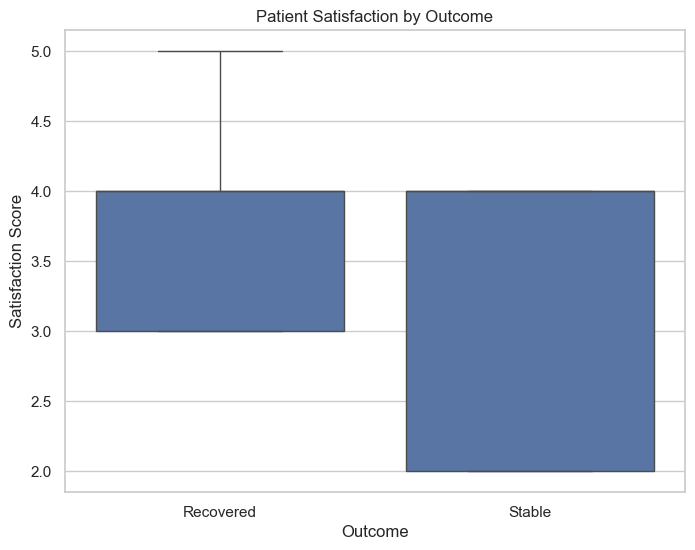

In [68]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=hospital_analysis,
    x="Outcome",
    y="Satisfaction"
)

plt.title("Patient Satisfaction by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Satisfaction Score")

plt.show()

### Interpretation

Patient satisfaction varies between the recorded outcome groups.

If recovered patients report higher satisfaction, this would suggest that successful recovery may be associated with a better patient experience.

However, satisfaction is subjective and may also depend on factors such as communication, waiting time, treatment experience, and hospital environment, which are not captured in this dataset.

## Patient Satisfaction and Readmission

This analysis investigates whether satisfaction differs between patients who were readmitted and those who were not.

If a meaningful difference is observed, it may provide an area for further investigation into follow-up care and the patient experience.

However, satisfaction alone cannot be used to determine the cause of readmission.

In [69]:
hospital_analysis.groupby("Readmission")["Satisfaction"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Readmission,,,
No,720,3.776389,4.0
Yes,264,3.113636,3.0


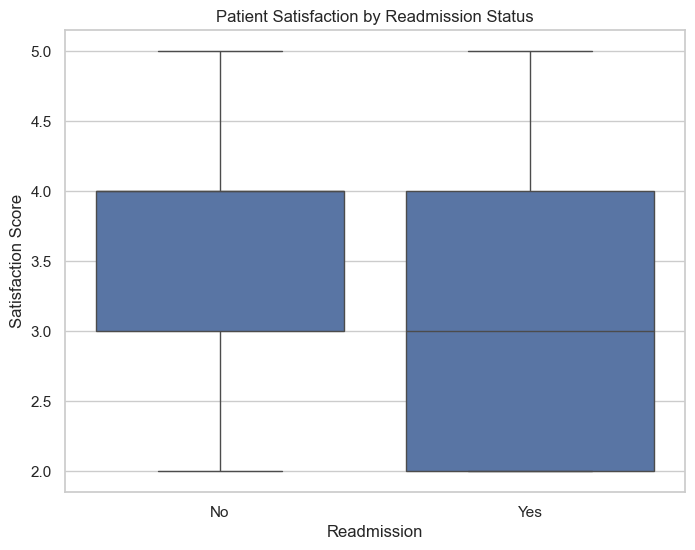

In [70]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=hospital_analysis,
    x="Readmission",
    y="Satisfaction"
)

plt.title("Patient Satisfaction by Readmission Status")
plt.xlabel("Readmission")
plt.ylabel("Satisfaction Score")

plt.show()

### Interpretation

The average satisfaction score differs between patients who were readmitted and those who were not.

This may indicate that patient experience is associated with readmission patterns. However, satisfaction alone cannot explain why a patient was readmitted.

Factors such as medical condition, treatment complexity, recovery progress, and follow-up care may influence both satisfaction and readmission.

## Does Age Relate to Patient Outcome?

I will investigate whether patient age differs between patients who recovered and those who remained stable.

This may help determine whether age is associated with differences in recorded outcomes.

In [72]:
hospital_analysis.groupby("Outcome")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Outcome,,,,,
Recovered,591,45.297800,45.0,25,67
Stable,393,66.470738,68.0,48,78


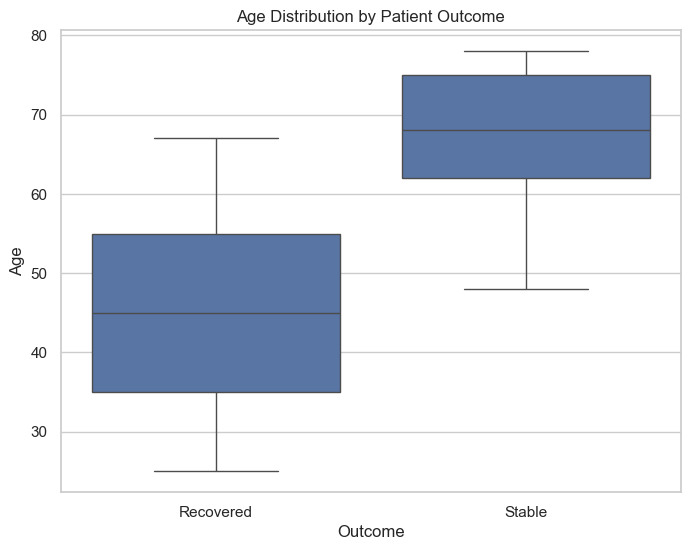

In [73]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=hospital_analysis,
    x="Outcome",
    y="Age"
)

plt.title("Age Distribution by Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.show()

This shows that patients within ages 30 to 60 recover well, while patients within ages 60 to 80 become stable.

In [71]:
summary_by_condition = hospital_analysis.groupby("Condition").agg(
    Patients=("Patient_ID", "count"),
    Average_Age=("Age", "mean"),
    Average_Cost=("Cost", "mean"),
    Average_Stay=("Length_of_Stay", "mean"),
    Average_Satisfaction=("Satisfaction", "mean")
).sort_values("Average_Cost", ascending=False)

summary_by_condition.round(2)

,Patients,Average_Age,Average_Cost,Average_Stay,Average_Satisfaction
Condition,,,,,
Cancer,66,53.92,25000.0,42.65,4.00
Prostate Cancer,65,62.54,20000.0,41.58,3.00
Heart Attack,67,76.40,18000.0,41.00,2.00
Heart Disease,65,51.51,15000.0,38.22,3.49
Childbirth,65,33.45,12000.0,35.52,4.00
Stroke,66,74.08,10000.0,40.33,2.00
Appendicitis,66,52.65,8000.0,37.44,3.00
Kidney Stones,65,52.49,6000.0,36.46,3.00
Osteoarthritis,64,62.47,4000.0,37.86,4.00


# Conclusion

This analysis examined 984 hospital patient records to identify patterns in patient demographics, medical conditions, procedures, healthcare costs, length of hospital stay, readmission, outcomes, and patient satisfaction.

The dataset contained a relatively balanced distribution of medical conditions, with each condition represented by approximately 64 to 67 patients. Female patients were slightly more numerous than male patients.

Age showed noticeable differences across medical conditions. Heart Attack and Stroke were associated with the oldest average patient ages, while Allergic Reaction and Fractured Arm were associated with younger average ages.

Length of hospital stay also differed across conditions, with Cancer having the highest average stay. However, the correlation between length of stay and cost was only approximately 0.11, indicating that length of stay alone was not a strong predictor of healthcare cost in this dataset.

Healthcare costs differed substantially across medical conditions, suggesting that the type of condition and its associated treatment may be more important cost factors than hospital stay duration alone.

The analysis of procedures further helps investigate whether age, cost, length of stay, readmission, and patient outcomes differ according to the treatment received.

Finally, patient satisfaction provides an additional perspective on healthcare quality. Clinical outcomes and patient experience should be considered together rather than assuming that recovery automatically means high patient satisfaction.

Overall, the analysis demonstrates that healthcare data should not be examined using a single variable. Combining demographic, clinical, financial, and patient-experience variables provides a more complete understanding of the patterns within the dataset.

# Recommendations

1. **Focus on high-cost conditions:** Conditions associated with substantially higher costs should be investigated further to understand which procedures or treatment factors contribute to the additional expenditure.

2. **Monitor conditions affecting older patients:** Conditions such as heart attack, stroke, hypertension, and diabetes show higher average patient ages in this dataset. Age-specific monitoring and prevention strategies could be explored.

3. **Improve discharge and care planning:** Conditions associated with longer hospital stays should be reviewed to identify opportunities for better
discharge planning and continuity of care.

4. **Investigate readmission patterns:** Procedures or conditions with higher readmission rates should be examined further to determine whether follow-up care, treatment complexity, or patient characteristics may contribute.

5. **Monitor patient satisfaction:** Satisfaction should be considered alongside clinical outcomes. Procedures or patient groups with lower satisfaction may require further investigation into the patient experience.

6. **Use gender-specific analysis carefully:** Differences in medical conditions between males and females should be monitored, but explanations should not be assumed without supporting clinical or demographic data.

7. **Avoid relying on a single indicator:** Cost, length of stay, outcome, readmission, and satisfaction measure different aspects of healthcare. Combining them provides a more reliable picture of patient and hospital performance.

8. **Collect additional variables:** Future datasets could include treatment details, severity of illness, complications, follow-up information, and reasons for readmission. These variables would allow deeper investigation of the relationships identified in this analysis.